In [7]:
import pandas as pd

# Load the raw data
df = pd.read_csv('data/retail_price.csv')
print(f"Original shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows of relevant columns:")
df[['product_id', 'unit_price', 'qty']].head(10)

Original shape: (676, 30)

Columns: ['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']

First few rows of relevant columns:


,product_id,unit_price,qty
0,bed1,45.950000,1
1,bed1,45.950000,3
2,bed1,45.950000,6
3,bed1,45.950000,4
4,bed1,45.950000,2
5,bed1,45.950000,3
6,bed1,40.531818,11
7,bed1,39.990000,6
8,bed1,39.990000,19
9,bed1,39.990000,18


In [8]:
# Check unique products and their data distribution
print(f"Unique products: {df['product_id'].nunique()}")
print(f"\nProducts and their row counts:")
print(df['product_id'].value_counts())


Unique products: 52

Products and their row counts:
product_id
health5       20
health7       20
bed2          19
garden1       18
health9       18
garden3       18
computers4    18
health8       17
watches1      17
garden9       17
garden2       17
garden7       16
garden10      16
garden6       16
bed1          16
computers1    15
cool1         15
watches3      15
watches2      15
garden5       14
garden4       14
garden8       14
watches6      14
perfumery2    13
cool2         13
furniture2    13
health2       13
furniture1    13
perfumery1    13
cool5         13
watches7      12
furniture3    12
consoles1     12
health4       11
bed3          11
computers3    10
computers2    10
bed4          10
consoles2     10
watches4      10
watches5      10
furniture4    10
watches8      10
health1        9
cool4          9
computers6     8
computers5     8
health3        8
cool3          7
health10       7
health6        7
bed5           5
Name: count, dtype: int64


In [9]:
# # Extract category from product_id (remove trailing numbers)
import re

df['category'] = df['product_id'].apply(lambda x: re.sub(r'\d+$', '', x))

print(f"Unique categories: {df['category'].nunique()}")
print(f"\nCategories and their row counts:")
print(df['category'].value_counts())


Unique categories: 9

Categories and their row counts:
category
garden       160
health       130
watches      103
computers     69
bed           61
cool          57
furniture     48
perfumery     26
consoles      22
Name: count, dtype: int64


In [10]:
# Pick a category
category_name = 'garden'  # Change to: health, watches, computers, bed, cool, furniture, perfumery, or consoles

df_category = df[df['category'] == category_name][['unit_price', 'qty']].copy()
df_category.columns = ['price', 'sales']

print(f"Category: {category_name}")
print(f"Rows: {len(df_category)}")
print(f"Price range: ${df_category['price'].min():.2f} - ${df_category['price'].max():.2f}")
print(f"Sales range: {df_category['sales'].min()} - {df_category['sales'].max()}")
print(f"\nPreview:")
df_category.head(10)


Category: garden
Rows: 160
Price range: $49.90 - $187.85
Sales range: 1 - 91

Preview:


,price,sales
16,69.900000,6
17,82.633333,3
18,97.588235,20
19,89.000000,8
20,89.000000,10
21,97.333333,7
22,99.000000,9
23,99.000000,14
24,99.000000,17
25,99.000000,11


Correlation (price vs sales): -0.2980


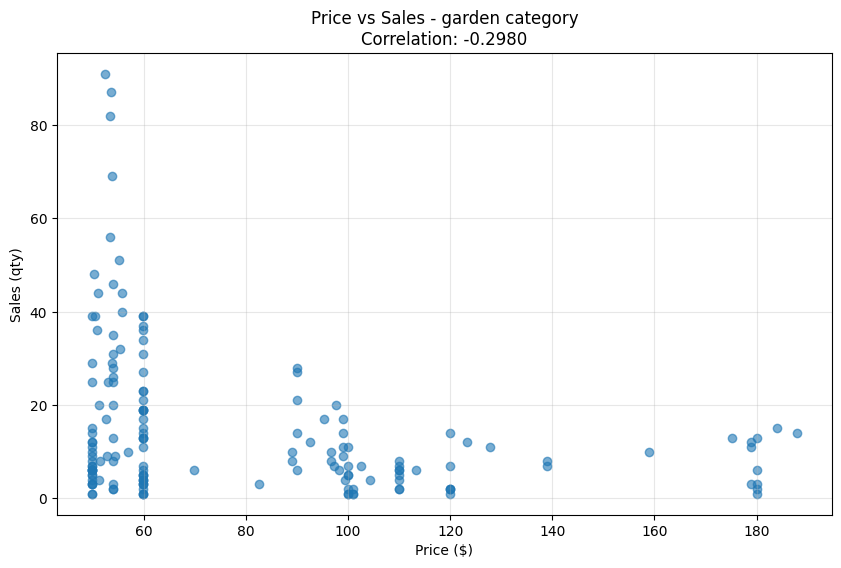

In [11]:
import matplotlib.pyplot as plt

# Correlation
correlation = df_category['price'].corr(df_category['sales'])
print(f"Correlation (price vs sales): {correlation:.4f}")

# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df_category['price'], df_category['sales'], alpha=0.6)
plt.xlabel('Price ($)')
plt.ylabel('Sales (qty)')
plt.title(f'Price vs Sales - {category_name} category\nCorrelation: {correlation:.4f}')
plt.grid(True, alpha=0.3)
plt.show()


In [12]:
# Check correlation for all categories
print("Correlation (price vs sales) by category:\n")
for cat in df['category'].unique():
    temp = df[df['category'] == cat]
    corr = temp['unit_price'].corr(temp['qty'])
    print(f"{cat:12} : {corr:+.4f}  ({len(temp)} rows)")


Correlation (price vs sales) by category:

bed          : +0.3711  (61 rows)
garden       : -0.2980  (160 rows)
consoles     : -0.5664  (22 rows)
health       : -0.1869  (130 rows)
cool         : -0.1015  (57 rows)
perfumery    : -0.2584  (26 rows)
computers    : +0.0699  (69 rows)
watches      : -0.2411  (103 rows)
furniture    : +0.1013  (48 rows)


All categories combined:
Rows: 676
Price range: $19.90 - $364.00
Sales range: 1 - 122
Correlation: -0.1034


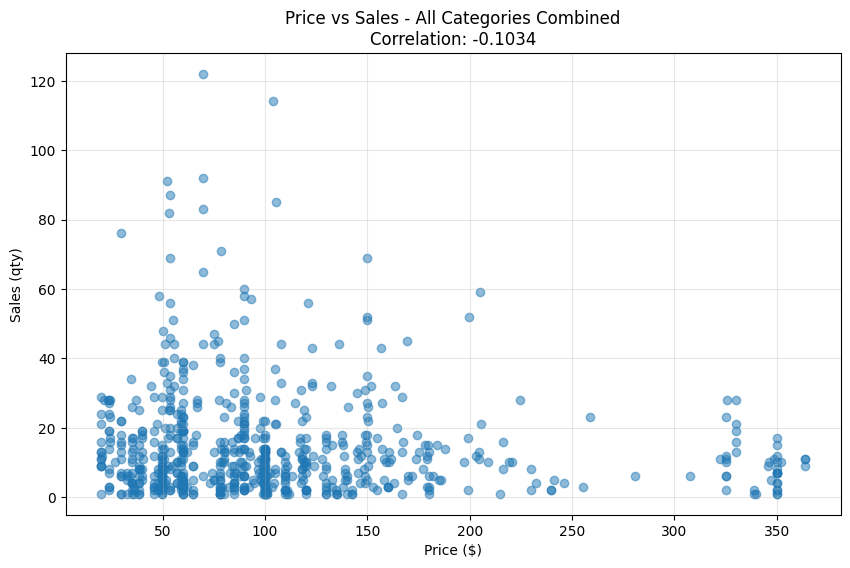

In [13]:
# Combine all categories
df_all = df[['unit_price', 'qty']].copy()
df_all.columns = ['price', 'sales']

# Correlation
correlation_all = df_all['price'].corr(df_all['sales'])
print(f"All categories combined:")
print(f"Rows: {len(df_all)}")
print(f"Price range: ${df_all['price'].min():.2f} - ${df_all['price'].max():.2f}")
print(f"Sales range: {df_all['sales'].min()} - {df_all['sales'].max()}")
print(f"Correlation: {correlation_all:.4f}")

# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df_all['price'], df_all['sales'], alpha=0.5)
plt.xlabel('Price ($)')
plt.ylabel('Sales (qty)')
plt.title(f'Price vs Sales - All Categories Combined\nCorrelation: {correlation_all:.4f}')
plt.grid(True, alpha=0.3)
plt.show()


In [14]:
# Show all columns with descriptions
print("All available columns:\n")
print(df.columns.tolist())

print("\n\nSample of potentially useful columns:")
df[['unit_price', 'qty', 'customers', 'product_score', 'freight_price', 
    'comp_1', 'comp_2', 'comp_3', 'holiday', 'weekend', 'month']].head(10)


All available columns:

['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price', 'category']


Sample of potentially useful columns:


,unit_price,qty,customers,product_score,freight_price,comp_1,comp_2,comp_3,holiday,weekend,month
0,45.950000,1,57,4.0,15.100000,89.900000,215.000000,45.950000,1,8,5
1,45.950000,3,61,4.0,12.933333,89.900000,209.000000,45.950000,1,8,6
2,45.950000,6,123,4.0,14.840000,89.900000,205.000000,45.950000,1,10,7
3,45.950000,4,90,4.0,14.287500,89.900000,199.509804,45.950000,1,8,8
4,45.950000,2,54,4.0,15.100000,89.900000,163.398710,45.950000,1,9,9
5,45.950000,3,50,4.0,15.100000,89.900000,45.950000,45.950000,2,9,10
6,40.531818,11,97,4.0,15.832727,89.900000,40.531818,40.531818,4,8,11
7,39.990000,6,41,4.0,15.230000,88.488235,39.990000,39.990000,1,10,12
8,39.990000,19,62,4.0,16.533684,86.900000,39.990000,39.990000,2,8,1
9,39.990000,18,62,4.0,13.749444,86.900000,39.990000,39.990000,2,8,2


In [15]:
# Check correlation of qty with all numeric columns
numeric_cols = ['unit_price', 'total_price', 'freight_price', 'product_score', 
                'customers', 'weekday', 'weekend', 'holiday', 'month',
                'comp_1', 'comp_2', 'comp_3', 'lag_price', 'volume', 'product_weight_g']

print("Correlation with qty (sales):\n")
correlations = {}
for col in numeric_cols:
    if col in df.columns:
        corr = df[col].corr(df['qty'])
        correlations[col] = corr
        print(f"{col:20} : {corr:+.4f}")

# Sort by absolute correlation
print("\n\nTop correlations (sorted by strength):")
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for col, corr in sorted_corr:
    print(f"{col:20} : {corr:+.4f}")


Correlation with qty (sales):

unit_price           : -0.1034
total_price          : +0.7496
freight_price        : -0.1355
product_score        : -0.0040
customers            : +0.4415
weekday              : +0.0309
weekend              : -0.0751
holiday              : +0.2116
month                : -0.0051
comp_1               : -0.0336
comp_2               : -0.0270
comp_3               : -0.0685
lag_price            : -0.0859
volume               : +0.0498
product_weight_g     : -0.0343


Top correlations (sorted by strength):
total_price          : +0.7496
customers            : +0.4415
holiday              : +0.2116
freight_price        : -0.1355
unit_price           : -0.1034
lag_price            : -0.0859
weekend              : -0.0751
comp_3               : -0.0685
volume               : +0.0498
product_weight_g     : -0.0343
comp_1               : -0.0336
weekday              : +0.0309
comp_2               : -0.0270
month                : -0.0051
product_score        : -0.004

Correlation (total_cost vs qty): -0.1173


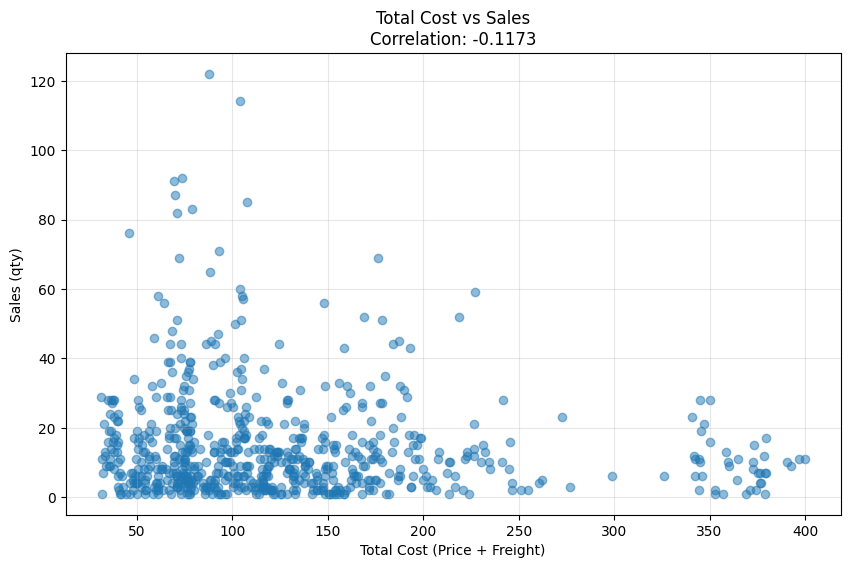

In [16]:
# Create total cost (what customer actually pays)
df['total_cost'] = df['unit_price'] + df['freight_price']

corr_total_cost = df['total_cost'].corr(df['qty'])
print(f"Correlation (total_cost vs qty): {corr_total_cost:.4f}")

# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df['total_cost'], df['qty'], alpha=0.5)
plt.xlabel('Total Cost (Price + Freight)')
plt.ylabel('Sales (qty)')
plt.title(f'Total Cost vs Sales\nCorrelation: {corr_total_cost:.4f}')
plt.grid(True, alpha=0.3)
plt.show()


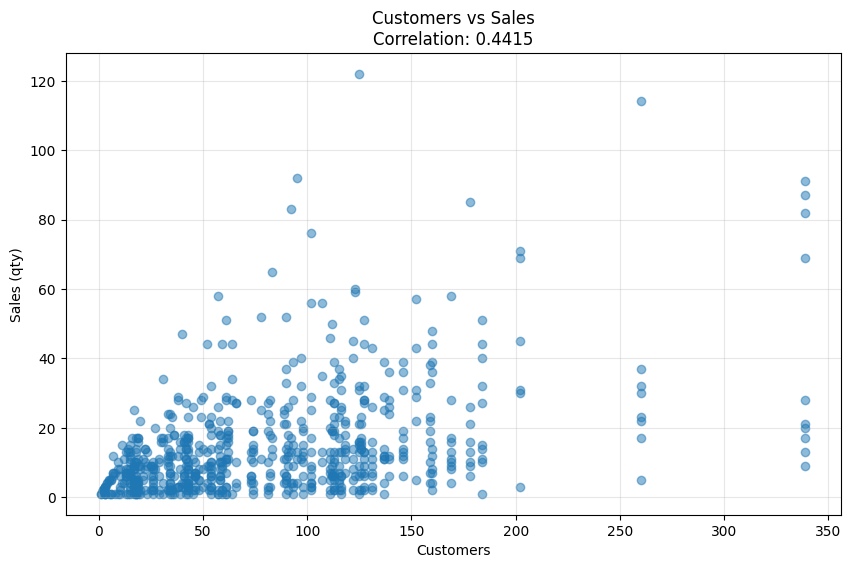

In [17]:
# Customers vs qty
plt.figure(figsize=(10, 6))
plt.scatter(df['customers'], df['qty'], alpha=0.5)
plt.xlabel('Customers')
plt.ylabel('Sales (qty)')
plt.title(f'Customers vs Sales\nCorrelation: {df["customers"].corr(df["qty"]):.4f}')
plt.grid(True, alpha=0.3)
plt.show()


Consoles category:
Rows: 22
Correlation: -0.5664
Price range: $19.90 - $36.20


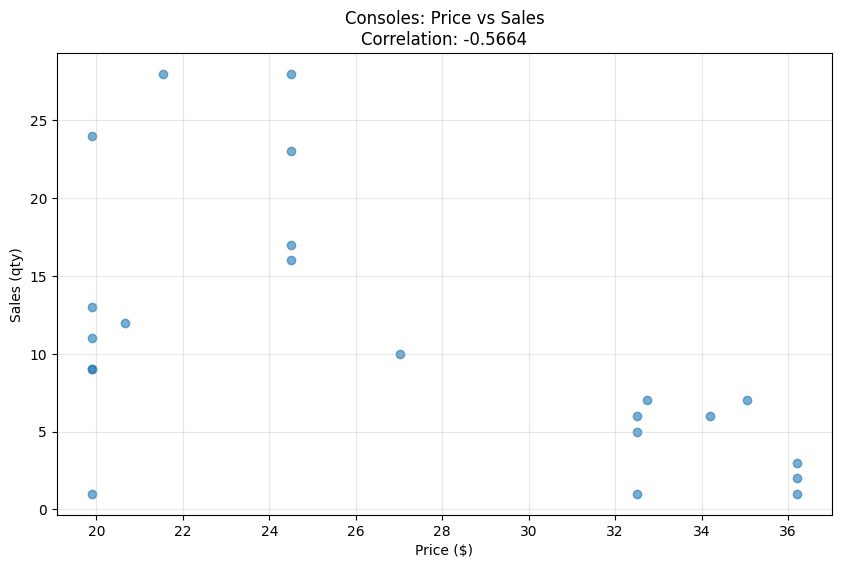

In [18]:
# Consoles - strongest price-demand relationship
df_consoles = df[df['category'] == 'consoles'][['unit_price', 'qty']].copy()
df_consoles.columns = ['price', 'sales']

corr = df_consoles['price'].corr(df_consoles['sales'])
print(f"Consoles category:")
print(f"Rows: {len(df_consoles)}")
print(f"Correlation: {corr:.4f}")
print(f"Price range: ${df_consoles['price'].min():.2f} - ${df_consoles['price'].max():.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(df_consoles['price'], df_consoles['sales'], alpha=0.6)
plt.xlabel('Price ($)')
plt.ylabel('Sales (qty)')
plt.title(f'Consoles: Price vs Sales\nCorrelation: {corr:.4f}')
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
# Save consoles data for the app
df_consoles.to_csv('data/consoles_pricing.csv', index=False)

print("File saved: data/consoles_pricing.csv")
print(f"\nReady for app.py with {len(df_consoles)} rows")
print(df_consoles.head(10))


File saved: data/consoles_pricing.csv

Ready for app.py with 22 rows
        price  sales
30  19.900000     13
31  19.900000     24
32  19.900000      9
33  21.542857     28
34  24.500000     28
35  24.500000     16
36  32.500000      5
37  32.500000      6
38  35.057143      7
39  36.200000      3
